# 02 — Bias Detection & Fairness Analysis

**Course:** Data Ecosystems and Governance in Organizations  
**Company:** NovaCred (fictional fintech)  
**Role:** Data Scientist  

---

## Objectives

This notebook investigates whether NovaCred's credit-scoring algorithm exhibits bias against protected groups. Specifically, we:

1. Compute the **Disparate Impact (DI) ratio** for gender and test against the four-fifths rule
2. Analyse **age-based** approval patterns
3. Explore **interaction effects** between gender and age
4. Investigate **proxy discrimination** — non-protected variables that may encode protected characteristics

> **Input:** `../data/cleaned_credit_applications.csv` (produced by `01-data-quality.ipynb`)

---
## 1. Setup

Import libraries and load the cleaned dataset.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# Colour palette — usada em todos os gráficos
PALETTE = {"Female": "#e07b7b", "Male": "#7bbde0"}
THRESHOLD_COLOR = "#d62728"  # vermelho para a linha DI = 0.80

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [19]:
df = pd.read_csv("../data/cleaned_credit_applications.csv")

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset shape: (500, 29)
Columns: ['_id', 'full_name', 'email', 'ssn', 'ip_address', 'gender', 'gender_raw', 'date_of_birth', 'date_of_birth_raw', 'age', 'zip_code', 'annual_income', 'annual_income_raw', 'income_imputed', 'credit_history_months', 'credit_history_months_flag', 'debt_to_income', 'dti_flag', 'savings_balance', 'loan_approved', 'interest_rate', 'approved_amount', 'rejection_reason', 'total_spending', 'alcohol_spend', 'email_missing', 'ssn_missing', 'dob_missing', 'ssn_conflict']


In [2]:
df.head()

,_id,full_name,email,ssn,ip_address,gender,gender_raw,date_of_birth,date_of_birth_raw,age,...,loan_approved,interest_rate,approved_amount,rejection_reason,total_spending,alcohol_spend,email_missing,ssn_missing,dob_missing,ssn_conflict
0,app_200,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,Male,2001-03-09,2001-03-09,24.0,...,False,NaN,NaN,algorithm_risk_score,1517,247,False,False,False,False
1,app_037,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,M,1992-03-31,1992-03-31,33.0,...,False,NaN,NaN,algorithm_risk_score,947,0,False,False,False,False
2,app_215,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,Male,1989-10-24,1989-10-24,36.0,...,True,3.7,59000.0,NaN,109,0,False,False,False,False
3,app_024,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,Male,1983-04-25,1983-04-25,42.0,...,True,4.3,34000.0,NaN,575,0,False,False,False,False
4,app_184,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,Male,M,1999-05-21,1999-05-21,26.0,...,False,NaN,NaN,algorithm_risk_score,463,0,False,False,False,False


In [ ]:
# data check
key_cols = ["gender", "age", "loan_approved", "annual_income",
            "credit_history_months", "zip_code", "alcohol_spend"]

print("Null counts in key columns:")
print(df[key_cols].isnull().sum())
print()
print("Gender distribution (after cleaning):")
print(df["gender"].value_counts())
print()
print("Loan approved distribution:")
print(df["loan_approved"].value_counts())
print(f"\nOverall approval rate: {df['loan_approved'].mean():.1%}")

Null counts in key columns:
gender                   2
age                      4
loan_approved            0
annual_income            0
credit_history_months    0
zip_code                 1
alcohol_spend            0
dtype: int64

Gender distribution (after cleaning):
gender
Female    251
Male      247
Name: count, dtype: int64

Loan approved distribution:
loan_approved
True     292
False    208
Name: count, dtype: int64

Overall approval rate: 58.4%


---
## 2. Gender Disparate Impact

The **Disparate Impact (DI) ratio** measures whether an unprivileged group receives positive outcomes at a significantly lower rate than a privileged group.

$$DI = \frac{\text{Approval rate (Female)}}{\text{Approval rate (Male)}}$$

The **four-fifths rule** (80% rule) is the standard legal threshold:
- DI **< 0.80** → potential disparate impact (violation)
- DI **≥ 0.80** → no disparate impact detected

In [21]:
approval_by_gender = (
    df.groupby("gender")["loan_approved"]
      .agg(["count", "mean"])
      .rename(columns={"count": "n_applications", "mean": "approval_rate"})
)

print(approval_by_gender)

        n_applications  approval_rate
gender                               
Female             251       0.505976
Male               247       0.659919


In [22]:
rate_female = approval_by_gender.loc["Female", "approval_rate"]
rate_male   = approval_by_gender.loc["Male",   "approval_rate"]

DI  = rate_female / rate_male
gap = rate_male - rate_female

print(f"Approval rate — Female: {rate_female:.1%}")
print(f"Approval rate — Male:   {rate_male:.1%}")
print(f"Approval gap:           {gap:.1%}")
print(f"Disparate Impact (DI):  {DI:.4f}")
print()
if DI < 0.8:
    print("⚠️  DI < 0.80 — POTENTIAL DISPARATE IMPACT DETECTED (four-fifths rule violated)")
else:
    print("✅  DI ≥ 0.80 — No disparate impact detected")

Approval rate — Female: 50.6%
Approval rate — Male:   66.0%
Approval gap:           15.4%
Disparate Impact (DI):  0.7667

⚠️  DI < 0.80 — POTENTIAL DISPARATE IMPACT DETECTED (four-fifths rule violated)


### Visualisation — Approval Rate by Gender

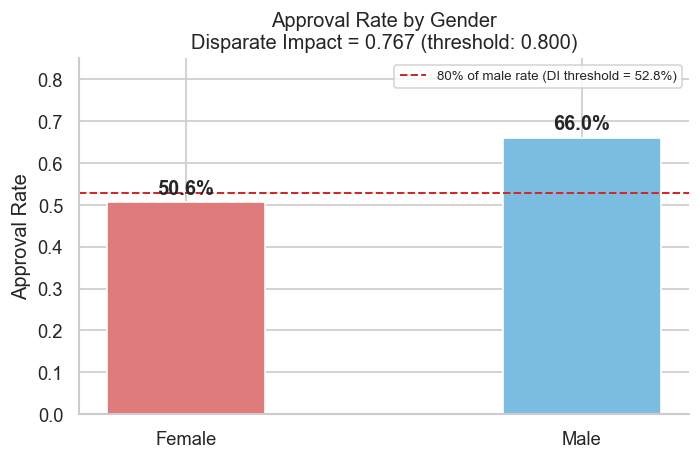

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))

genders = ["Female", "Male"]
rates   = [rate_female, rate_male]
colors  = [PALETTE["Female"], PALETTE["Male"]]

bars = ax.bar(genders, rates, color=colors, width=0.4, edgecolor="white")

# Linha do threshold DI = 0.80
threshold = 0.8 * rate_male
ax.axhline(threshold, color=THRESHOLD_COLOR, linestyle="--", linewidth=1.2,
           label=f"80% of male rate (DI threshold = {threshold:.1%})")

# Etiquetas em cima de cada barra
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{rate:.1%}", ha="center", va="bottom", fontweight="bold")

ax.set_ylim(0, 0.85)
ax.set_ylabel("Approval Rate")
ax.set_title(f"Approval Rate by Gender\nDisparate Impact = {DI:.3f} (threshold: 0.800)")
ax.legend(fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

---
## 3. Age-Based Bias

Age is a protected characteristic. We analyse whether approval rates differ significantly across age groups.

In [25]:
df["age_bin"] = pd.cut(
    df["age"],
    bins=[18, 29, 39, 49, 59, 100],
    labels=["18-29", "30-39", "40-49", "50-59", "60+"]
)

approval_by_age = (
    df.groupby("age_bin", observed=False)["loan_approved"]
      .agg(["count", "mean"])
      .rename(columns={"count": "n_applications", "mean": "approval_rate"})
)

print(approval_by_age)

         n_applications  approval_rate
age_bin                               
18-29                82       0.414634
30-39               171       0.567251
40-49               138       0.688406
50-59                62       0.564516
60+                  43       0.651163


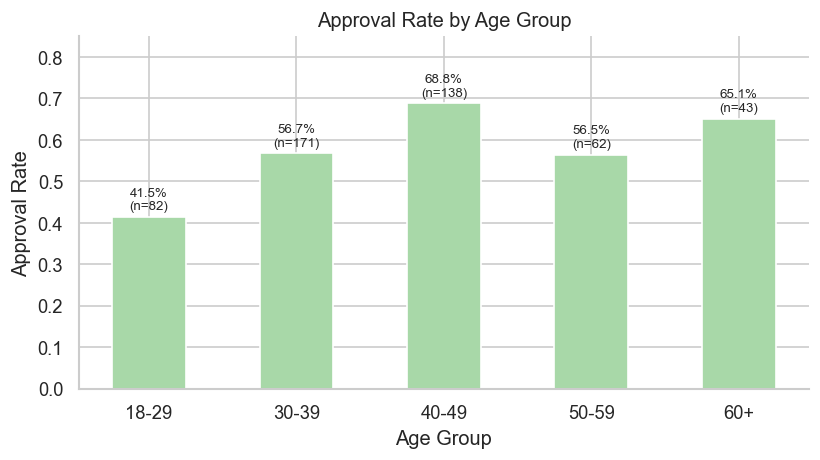

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    approval_by_age.index,
    approval_by_age["approval_rate"],
    color="#a8d8a8", edgecolor="white", width=0.5
)

for bar, (_, row) in zip(bars, approval_by_age.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{row['approval_rate']:.1%}\n(n={row['n_applications']:.0f})",
            ha="center", va="bottom", fontsize=8)

ax.set_ylim(0, 0.85)
ax.set_xlabel("Age Group")
ax.set_ylabel("Approval Rate")
ax.set_title("Approval Rate by Age Group")
sns.despine()
plt.tight_layout()
plt.show()

---
## 4. Interaction Effect: Gender × Age

A gender gap at the overall level may hide variation across age groups. Here we compute the DI ratio **within each age group** to detect where the bias is most severe.